# Load grokked model

Loads the trained `GrokModel` checkpoint and runs a few sanity checks.

In [281]:
import os, sys
import torch

sys.path.append(os.path.join(os.getcwd(), ".."))
from interpreting.load_model import load_model, get_device, sanity_check, predict

Using device: mps
Loading full checkpoint: ../model/checkpoints/grok_checkpoint.pt
Using model.embedding.weight, shape after slicing: (128, 113)
||F F^T - I||_F = 1.28e-13
||W_E||_F^2 = 26.0517    sum_k E_k = 26.0517   (Parseval)
Top 10 frequencies by energy:
  k =  35    E_k =    7.455    (28.62% of total)
  k =   3    E_k =    7.121    (27.34% of total)
  k =  10    E_k =    6.415    (24.62% of total)
  k =  43    E_k =    1.464    ( 5.62% of total)
  k =   6    E_k =    1.160    ( 4.45% of total)
  k =  20    E_k =    0.986    ( 3.78% of total)
  k =   0    E_k =    0.276    ( 1.06% of total)
  k =   8    E_k =    0.096    ( 0.37% of total)
  k =  38    E_k =    0.090    ( 0.34% of total)
  k =  32    E_k =    0.080    ( 0.31% of total)
Identified key frequencies: [3, 6, 10, 35, 43]
Plotting per-row spectra for rows: [0, 1, 5]


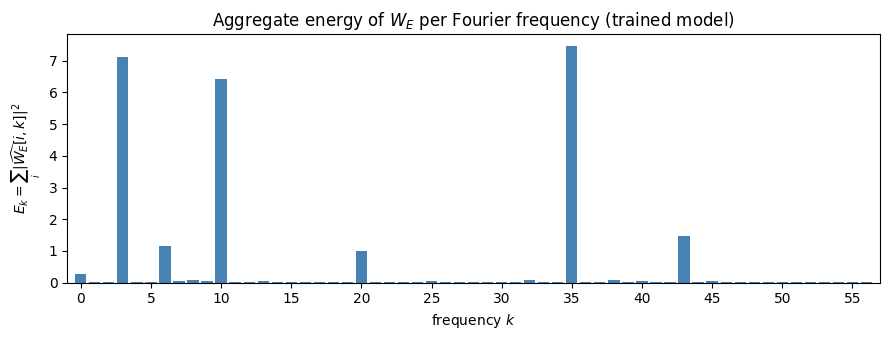

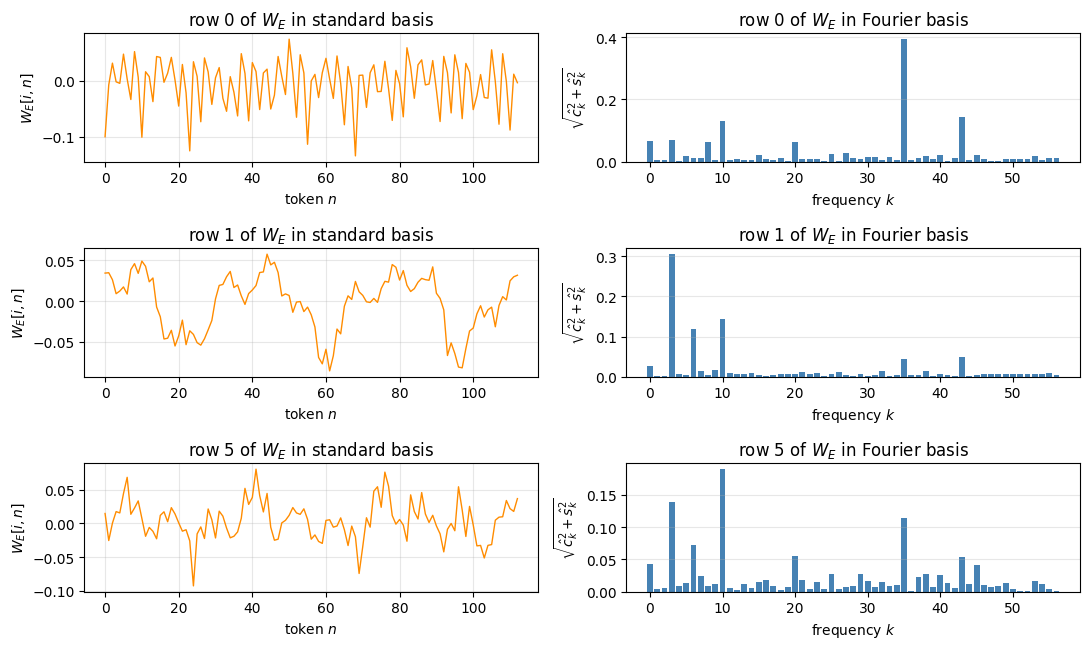

In [282]:
device = get_device()
print(f"Using device: {device}")

ckpt_dir = os.path.join("..", "model", "checkpoints")
ckpt_path = os.path.join(ckpt_dir, "grok_checkpoint.pt")
weights_path = os.path.join(ckpt_dir, "grok_model.pt")

if os.path.exists(ckpt_path):
    print(f"Loading full checkpoint: {ckpt_path}")
    model, ckpt = load_model(checkpoint_path=ckpt_path, device=device)
else:
    print(f"Loading weights only: {weights_path}")
    model, ckpt = load_model(weights_only_path=weights_path, device=device)

import numpy as np
import matplotlib.pyplot as plt


# -----------------------------------------------------------------------------
# 1. Extract W_E from the model
# -----------------------------------------------------------------------------

def extract_W_E(model, p: int) -> np.ndarray:
    """
    Pull the (d, p) embedding matrix out of the model.

    Tries a few common attribute paths used in mechanistic-interpretability
    repos. If none match, prints the model and named parameters so you can
    pick the right path manually.
    """
    candidates = [
        # (description, callable that returns a tensor)
        ("model.embed.W_E",          lambda m: m.embed.W_E),
        ("model.W_E",                lambda m: m.W_E),
        ("model.embedding.weight",   lambda m: m.embedding.weight),
        ("model.tok_embeddings.weight", lambda m: m.tok_embeddings.weight),
        ("model.token_embeddings.weight", lambda m: m.token_embeddings.weight),
    ]
    for name, getter in candidates:
        try:
            W = getter(model)
        except AttributeError:
            continue
        W = W.detach().cpu().numpy()
        # Normalize to shape (d, p): we want d (embedding dim) on axis 0,
        # p (number of tokens) on axis 1. Drop the '=' token if present.
        if W.shape[0] in (p, p + 1):           # stored as (vocab, d)
            W = W.T                            # -> (d, vocab)
        if W.shape[1] == p + 1:                # has '=' token at the end
            W = W[:, :p]
        if W.shape[1] != p:
            print(f"Found {name} with shape {W.shape} -- doesn't match p={p}, skipping.")
            continue
        print(f"Using {name}, shape after slicing: {W.shape}")
        return W
    # Fallback: tell the user what's available
    print("Could not auto-detect W_E. Named parameters in the model:")
    for n, t in model.named_parameters():
        print(f"  {n}    shape={tuple(t.shape)}")
    raise AttributeError("Adjust extract_W_E() to use the correct attribute path.")


# -----------------------------------------------------------------------------
# 2. Fourier basis matrix (orthonormal real basis on Z/pZ)
# -----------------------------------------------------------------------------

def fourier_basis_matrix(p: int) -> np.ndarray:
    assert p % 2 == 1, "this construction assumes p is odd"
    n = np.arange(p)
    rows = [np.ones(p) / np.sqrt(p)]
    for k in range(1, (p - 1) // 2 + 1):
        angle = 2 * np.pi * k * n / p
        rows.append(np.sqrt(2 / p) * np.cos(angle))
        rows.append(np.sqrt(2 / p) * np.sin(angle))
    return np.stack(rows, axis=0)


# -----------------------------------------------------------------------------
# 3. Change of basis + per-frequency energy
# -----------------------------------------------------------------------------

def to_fourier(W_E: np.ndarray, F: np.ndarray) -> np.ndarray:
    return W_E @ F.T


def per_frequency_energy(W_E_hat: np.ndarray, p: int) -> np.ndarray:
    num_freqs = (p - 1) // 2 + 1
    E = np.zeros(num_freqs)
    E[0] = np.sum(W_E_hat[:, 0] ** 2)
    for k in range(1, num_freqs):
        E[k] = np.sum(W_E_hat[:, 2 * k - 1] ** 2 + W_E_hat[:, 2 * k] ** 2)
    return E


# -----------------------------------------------------------------------------
# 4. Plotting
# -----------------------------------------------------------------------------

def plot_aggregate_energy(E: np.ndarray, savepath: str = "aggregate_energy.png"):
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.bar(np.arange(len(E)), E, width=0.8, color="steelblue")
    ax.set_xlabel("frequency $k$")
    ax.set_ylabel(r"$E_k = \sum_i |\widehat{W_E}[i,k]|^2$")
    ax.set_title(r"Aggregate energy of $W_E$ per Fourier frequency (trained model)")
    ax.set_xticks(np.arange(0, len(E), 5))
    ax.margins(x=0.01)
    fig.tight_layout()
    fig.savefig(savepath, dpi=150)
    plt.show()


def plot_per_row_spectra(W_E: np.ndarray, W_E_hat: np.ndarray, p: int,
                         row_indices, savepath: str = "per_row_spectra.png"):
    n = np.arange(p)
    nrows = len(row_indices)
    fig, axes = plt.subplots(nrows, 2, figsize=(11, 2.2 * nrows))
    if nrows == 1:
        axes = axes[None, :]
    num_freqs = (p - 1) // 2 + 1
    for ax_row, i in zip(axes, row_indices):
        ax_row[0].plot(n, W_E[i], color="darkorange", lw=1)
        ax_row[0].set_title(f"row {i} of $W_E$ in standard basis")
        ax_row[0].set_xlabel("token $n$"); ax_row[0].set_ylabel(r"$W_E[i, n]$")
        ax_row[0].grid(alpha=0.3)

        spectrum = np.zeros(num_freqs)
        spectrum[0] = abs(W_E_hat[i, 0])
        for k in range(1, num_freqs):
            spectrum[k] = np.sqrt(W_E_hat[i, 2 * k - 1] ** 2 + W_E_hat[i, 2 * k] ** 2)
        ax_row[1].bar(np.arange(num_freqs), spectrum, color="steelblue")
        ax_row[1].set_title(f"row {i} of $W_E$ in Fourier basis")
        ax_row[1].set_xlabel("frequency $k$"); ax_row[1].set_ylabel(r"$\sqrt{\hat{c}_k^2 + \hat{s}_k^2}$")
        ax_row[1].grid(alpha=0.3, axis="y")
    fig.tight_layout()
    fig.savefig(savepath, dpi=150)
    plt.show()


# -----------------------------------------------------------------------------
# 5. Run on the loaded model
# -----------------------------------------------------------------------------

p = 113   # change if your model uses a different prime

W_E = extract_W_E(model, p=p)
F = fourier_basis_matrix(p)

# sanity checks
print(f"||F F^T - I||_F = {np.linalg.norm(F @ F.T - np.eye(p)):.2e}")

W_E_hat = to_fourier(W_E, F)
E = per_frequency_energy(W_E_hat, p)
print(f"||W_E||_F^2 = {np.sum(W_E ** 2):.4f}    sum_k E_k = {np.sum(E):.4f}   (Parseval)")

# top frequencies
top = np.argsort(E)[::-1]
print("Top 10 frequencies by energy:")
for k in top[:10]:
    frac = E[k] / np.sum(E)
    print(f"  k = {k:3d}    E_k = {E[k]:8.3f}    ({100*frac:5.2f}% of total)")

# pick rows aligned with the top frequencies for the per-row plot
key_freqs = sorted(top[:5].tolist())
print(f"Identified key frequencies: {key_freqs}")

# find one row that's strongly aligned with each key frequency, for the per-row plot
def row_dominant_freq(i, W_E_hat, num_freqs):
    spec = np.zeros(num_freqs)
    spec[0] = abs(W_E_hat[i, 0])
    for k in range(1, num_freqs):
        spec[k] = np.sqrt(W_E_hat[i, 2*k-1]**2 + W_E_hat[i, 2*k]**2)
    return int(np.argmax(spec))

num_freqs = (p - 1) // 2 + 1
representative_rows = []
seen = set()
for i in range(W_E.shape[0]):
    k = row_dominant_freq(i, W_E_hat, num_freqs)
    if k in key_freqs and k not in seen:
        representative_rows.append(i)
        seen.add(k)
    if len(representative_rows) == len(key_freqs):
        break

if not representative_rows:
    representative_rows = [0, 1, 2, 3]
print(f"Plotting per-row spectra for rows: {representative_rows}")

plot_aggregate_energy(E)
plot_per_row_spectra(W_E, W_E_hat, p, row_indices=representative_rows)

In [283]:
if ckpt is not None:
    print(f"Trained for {ckpt['step']} steps.")
    print(f"Config: {ckpt['config']}")
    if "history" in ckpt and ckpt["history"]["test_acc"]:
        print(f"Final logged test acc: {ckpt['history']['test_acc'][-1]:.4f}")

Trained for 60000 steps.
Config: {'prime': 113, 'd_model': 128, 'num_heads': 4, 'd_mlp': 512, 'n_ctx': 3}
Final logged test acc: 1.0000


In [284]:
sanity_check(model);

Full-table accuracy: 0.0732  (935/12769)


In [285]:
predict(model, 42, 97)
predict(model, 0, 0)
predict(model, 112, 1)
predict(model, 56, 56);

42 + 97 mod 113 = 26 | model: 81 (p=0.442) ✗
0 + 0 mod 113 = 0 | model: 35 (p=0.234) ✗
112 + 1 mod 113 = 0 | model: 112 (p=0.794) ✗
56 + 56 mod 113 = 112 | model: 112 (p=0.979) ✓


## Training history

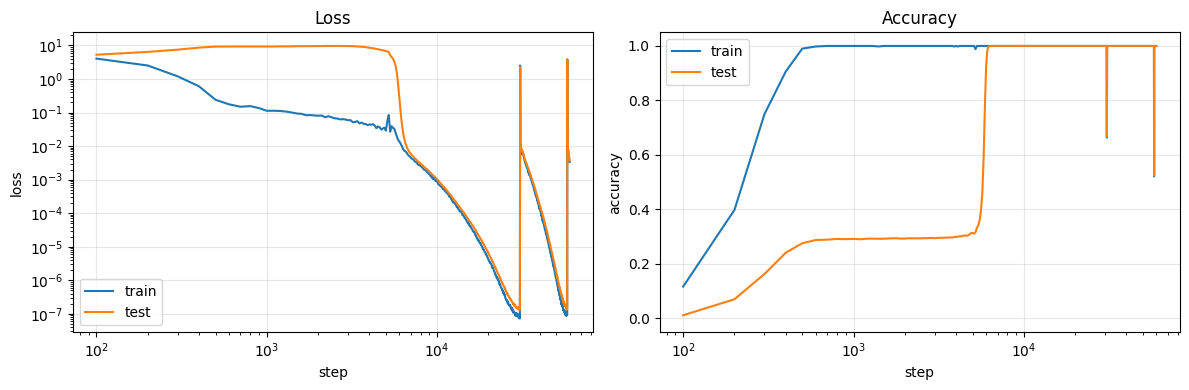

In [286]:
import matplotlib.pyplot as plt

if ckpt is not None and "history" in ckpt:
    h = ckpt["history"]
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

    ax_loss.plot(h["step"], h["train_loss"], label="train")
    ax_loss.plot(h["step"], h["test_loss"], label="test")
    ax_loss.set_xscale("log"); ax_loss.set_yscale("log")
    ax_loss.set_xlabel("step"); ax_loss.set_ylabel("loss")
    ax_loss.set_title("Loss"); ax_loss.legend(); ax_loss.grid(True, alpha=0.3)

    ax_acc.plot(h["step"], h["train_acc"], label="train")
    ax_acc.plot(h["step"], h["test_acc"], label="test")
    ax_acc.set_xscale("log")
    ax_acc.set_xlabel("step"); ax_acc.set_ylabel("accuracy")
    ax_acc.set_title("Accuracy"); ax_acc.set_ylim(-0.05, 1.05)
    ax_acc.legend(); ax_acc.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

## MLP neuron activations over (a, b)

Hook the post-ReLU activations of the MLP hidden layer at the `=` position, evaluated on every input pair `(a, b)` with `a, b ∈ [0, p)`. Each neuron then becomes a `p × p` image — one scalar per input pair.

In [287]:
import numpy as np

prime = 113

# All (a, b) pairs as input sequences [a, b, =]
pairs = torch.tensor(
    [[a, b, prime] for a in range(prime) for b in range(prime)],
    dtype=torch.long, device=device,
)

# Capture post-ReLU MLP activations via a forward hook on model.mlp.act
captured = {}
def _hook(_module, _inp, out):
    captured["acts"] = out.detach()

handle = model.mlp.act.register_forward_hook(_hook)
try:
    with torch.no_grad():
        model(pairs)
finally:
    handle.remove()

# captured["acts"]: [batch, n_ctx=3, d_mlp]; we want the "=" position (index 2)
acts = captured["acts"][:, 2, :].cpu().numpy()           # [p*p, d_mlp]
acts = acts.reshape(prime, prime, -1)                    # [a, b, neuron]
print(f"activations shape: {acts.shape}  (a, b, neuron)")

activations shape: (113, 113, 512)  (a, b, neuron)


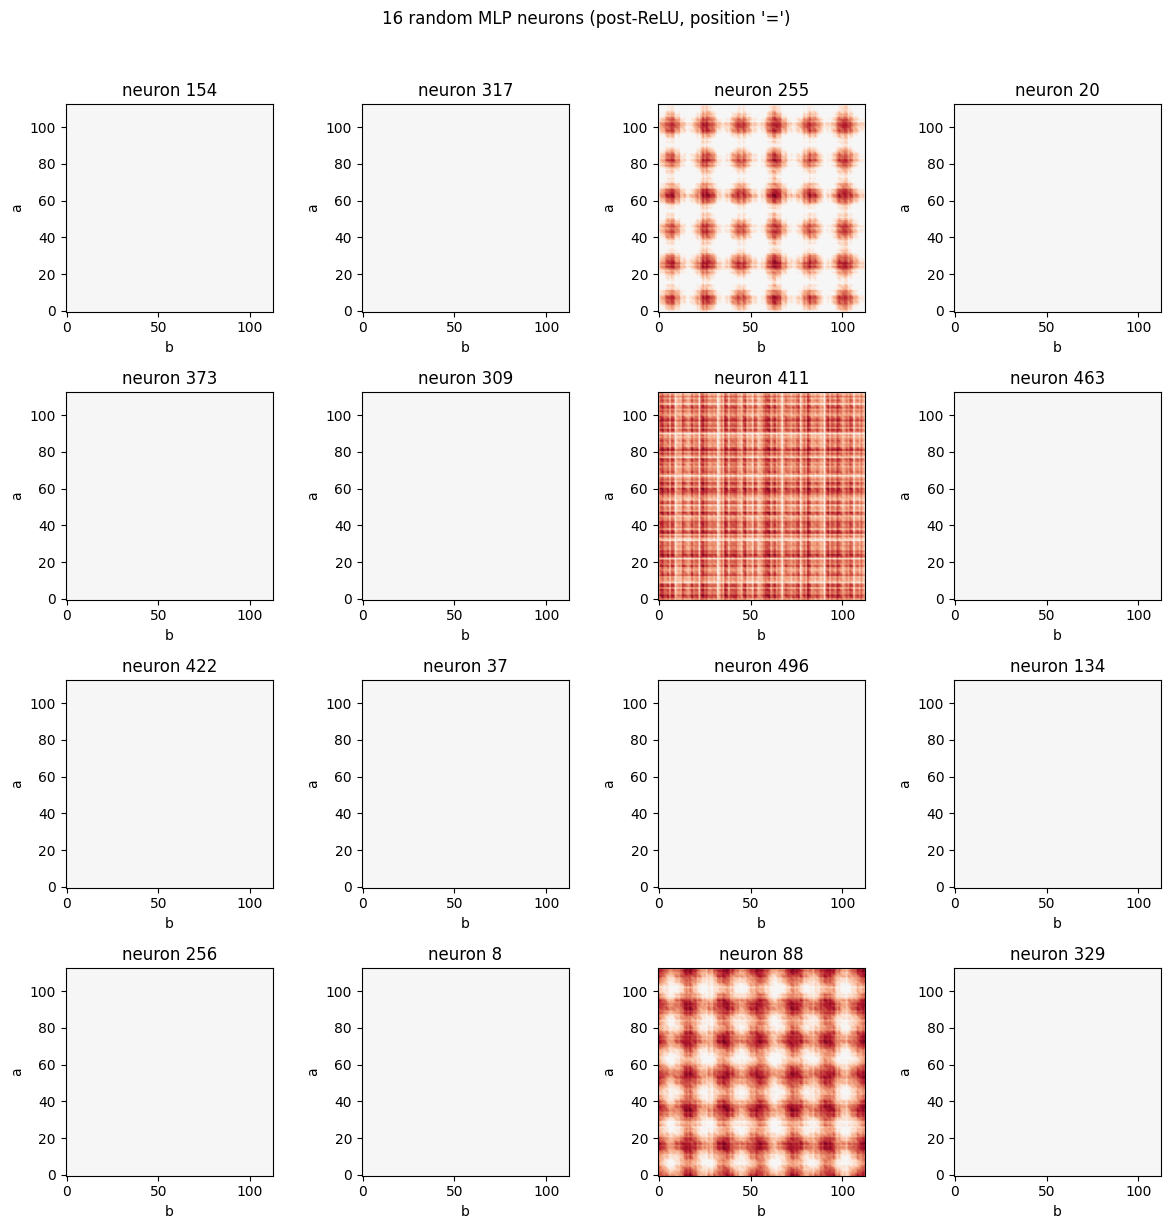

In [288]:
# Plot a random selection of neurons.
n_show = 16
rng = np.random.default_rng(0)
selected = rng.choice(acts.shape[-1], size=n_show, replace=False)

cols = 4
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
for ax, neuron in zip(axes.flat, selected):
    a_max = max(abs(acts[:, :, neuron]).max(), 1e-9)
    ax.imshow(acts[:, :, neuron], origin="lower", cmap="RdBu_r",
              vmin=-a_max, vmax=a_max)
    ax.set_title(f"neuron {neuron}")
    ax.set_xlabel("b"); ax.set_ylabel("a")
for ax in axes.flat[n_show:]:
    ax.axis("off")
fig.suptitle(f"{n_show} random MLP neurons (post-ReLU, position '=')", y=1.02)
plt.tight_layout(); plt.show()

### 2D Fourier spectra

If a neuron's activation is approximately `f(a, b) ≈ g(cos(2πk·a/p), cos(2πk·b/p), …)` for a single frequency `k`, its 2D FFT will concentrate energy at a few `(k_a, k_b)` peaks. For modular addition we expect the peaks to lie on `k_a = ±k_b` (the lines that depend only on `a+b`).

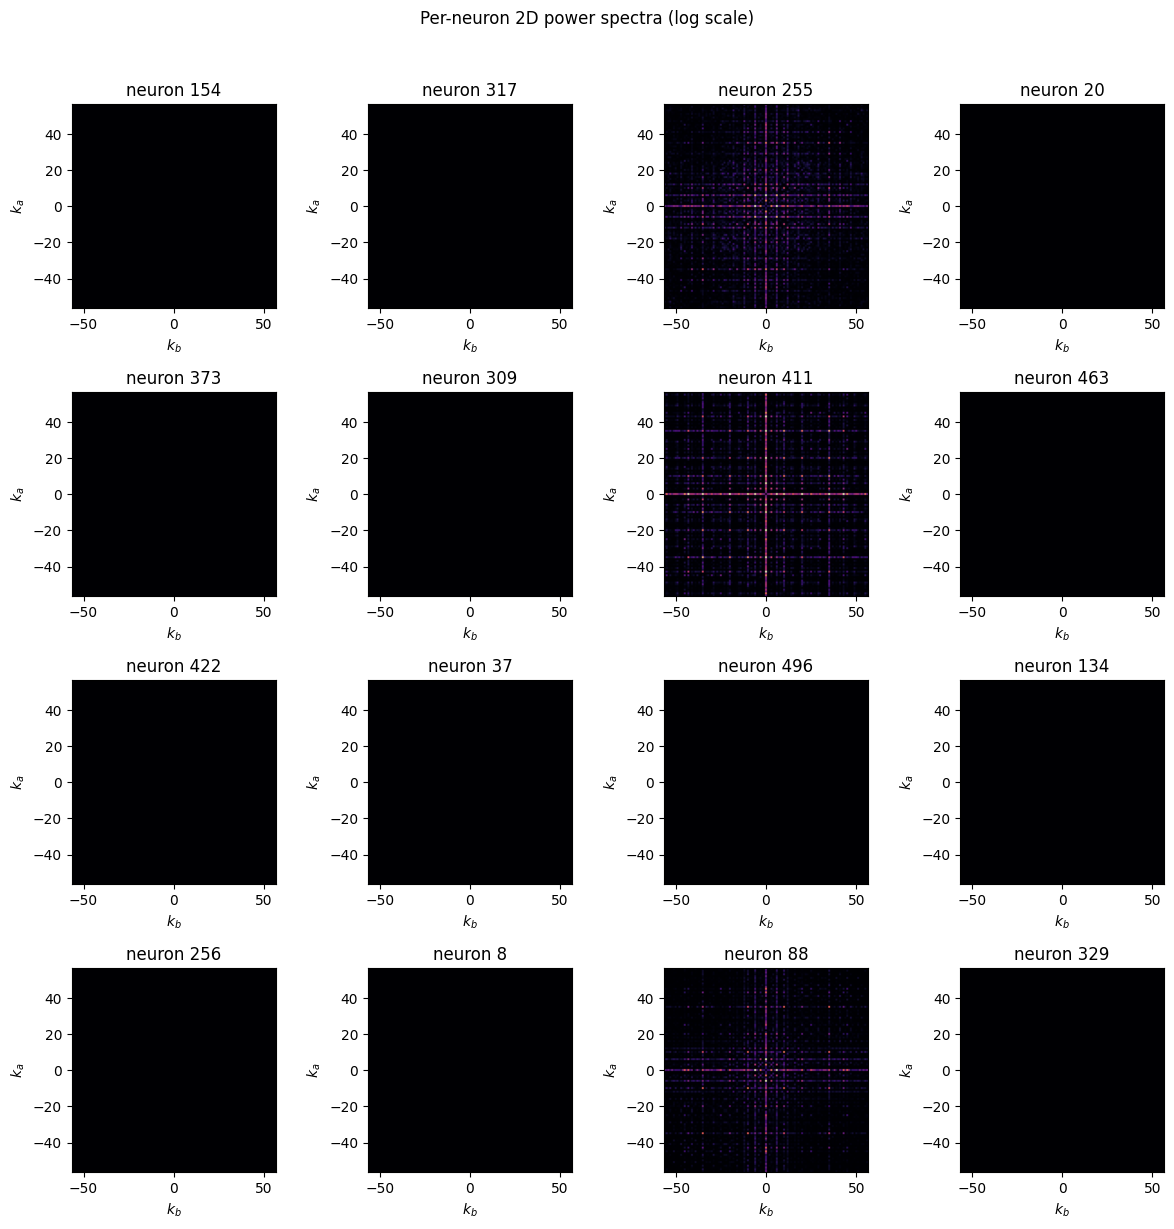

In [289]:
# 2D power spectrum of each neuron, mean-subtracted so the DC term doesn't dominate.
acts_centered = acts - acts.mean(axis=(0, 1), keepdims=True)
spec = np.fft.fftshift(np.fft.fft2(acts_centered, axes=(0, 1)), axes=(0, 1))
power = np.abs(spec) ** 2                                # [a-freq, b-freq, neuron]

freq = np.fft.fftshift(np.fft.fftfreq(prime, d=1.0)) * prime   # integer k, -p/2 .. p/2
extent = [freq[0] - 0.5, freq[-1] + 0.5, freq[0] - 0.5, freq[-1] + 0.5]

cols = 4
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
for ax, neuron in zip(axes.flat, selected):
    p = power[:, :, neuron]
    ax.imshow(np.log1p(p), origin="lower", extent=extent, cmap="magma")
    ax.set_title(f"neuron {neuron}")
    ax.set_xlabel("$k_b$"); ax.set_ylabel("$k_a$")
for ax in axes.flat[n_show:]:
    ax.axis("off")
fig.suptitle("Per-neuron 2D power spectra (log scale)", y=1.02)
plt.tight_layout(); plt.show()

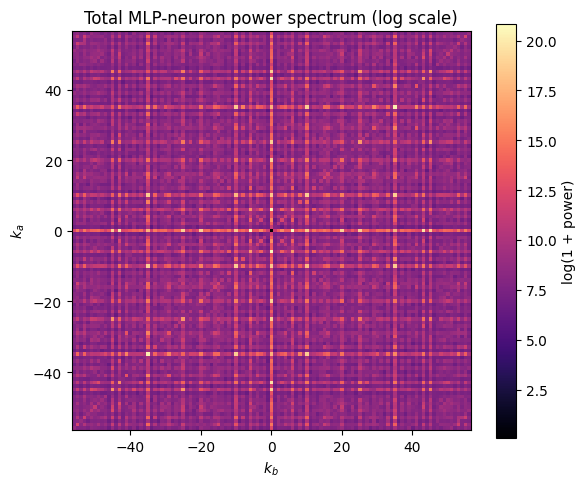

Top frequencies on k_a = k_b diagonal:
  k = +21   power = 5.87e+08
  k = -22   power = 5.87e+08
  k = +46   power = 1.39e+08
  k = -47   power = 1.39e+08
  k = +31   power = 1.38e+07
  k = -32   power = 1.38e+07
  k = +50   power = 1.21e+07
  k = -51   power = 1.21e+07


In [290]:
# Aggregate power across all neurons — this should reveal the k_a = ±k_b structure
# that's specific to functions of (a + b) mod p.
total_power = power.sum(axis=-1)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(np.log1p(total_power), origin="lower", extent=extent, cmap="magma")
ax.set_xlabel("$k_b$"); ax.set_ylabel("$k_a$")
ax.set_title("Total MLP-neuron power spectrum (log scale)")
plt.colorbar(im, ax=ax, label="log(1 + power)")
plt.tight_layout(); plt.show()

# Which frequencies the network actually uses, ranked by total power on the k_a = +k_b diagonal:
diag = np.array([total_power[i, i] for i in range(prime)])           # unshifted indexing
diag_freqs = np.fft.fftfreq(prime, d=1.0) * prime
order = np.argsort(diag)[::-1]
print("Top frequencies on k_a = k_b diagonal:")
for i in order[:8]:
    k = int(round(diag_freqs[i]))
    if k == 0:
        continue
    print(f"  k = {k:+d}   power = {diag[i]:.3g}")

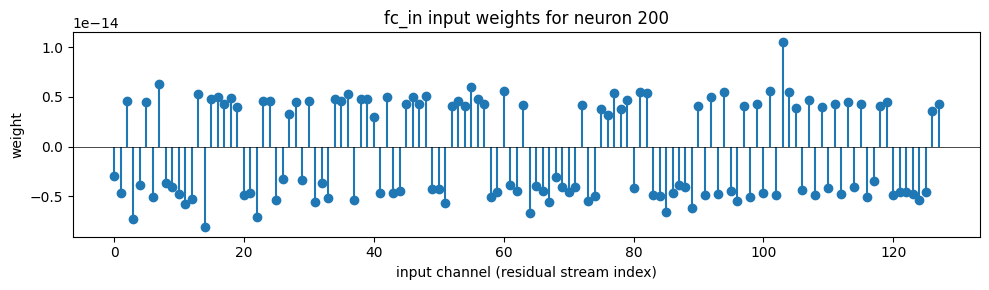

d_model = 128,  ‖w‖₂ = 0.000,  max|w| = 0.000


In [291]:
# Input weights of neuron 255 in fc_in: one weight per residual-stream channel.
neuron_id = 200
w = model.mlp.fc_in.weight[neuron_id].detach().cpu().numpy()   # shape [d_model]

fig, ax = plt.subplots(figsize=(10, 3))
ax.stem(np.arange(w.size), w, basefmt=" ")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("input channel (residual stream index)")
ax.set_ylabel("weight")
ax.set_title(f"fc_in input weights for neuron {neuron_id}")
plt.tight_layout(); plt.show()

print(f"d_model = {w.size},  ‖w‖₂ = {np.linalg.norm(w):.3f},  max|w| = {np.abs(w).max():.3f}")

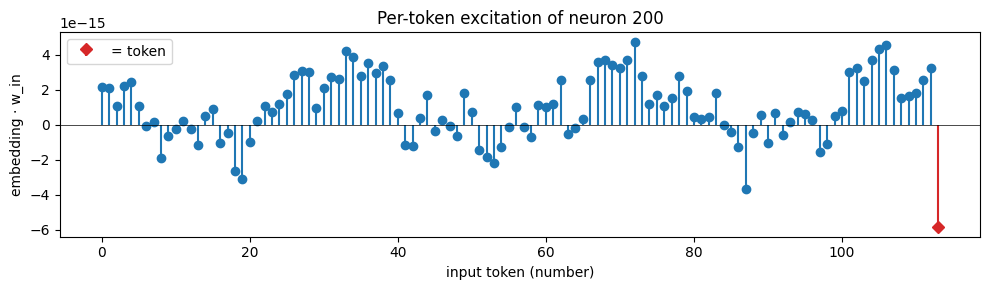

In [292]:
# Effective input weight per *token*: how much each vocab item excites neuron 255
# if its embedding lands in the MLP input (ignoring attention/pos-embedding mixing).
emb = model.embedding.weight.detach().cpu().numpy()       # [d_vocab, d_model]
per_token = emb @ w                                       # [d_vocab]

token_ids = np.arange(per_token.size)
fig, ax = plt.subplots(figsize=(10, 3))
ax.stem(token_ids[:prime], per_token[:prime], basefmt=" ", linefmt="C0-", markerfmt="C0o")
# the "=" token sits at index `prime`
ax.stem([prime], [per_token[prime]], basefmt=" ", linefmt="C3-", markerfmt="C3D",
        label="= token")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("input token (number)")
ax.set_ylabel("embedding · w_in")
ax.set_title(f"Per-token excitation of neuron {neuron_id}")
ax.legend()
plt.tight_layout(); plt.show()

In [293]:
W_E = model.embedding.weight

In [294]:
W_E.shape

torch.Size([114, 128])

In [295]:
W_E = extract_W_E(model, 113)

Using model.embedding.weight, shape after slicing: (128, 113)


In [296]:
W_E.shape

(128, 113)

In [297]:
X = np.fft.fft(W_E, axis=1)

<StemContainer object of 3 artists>

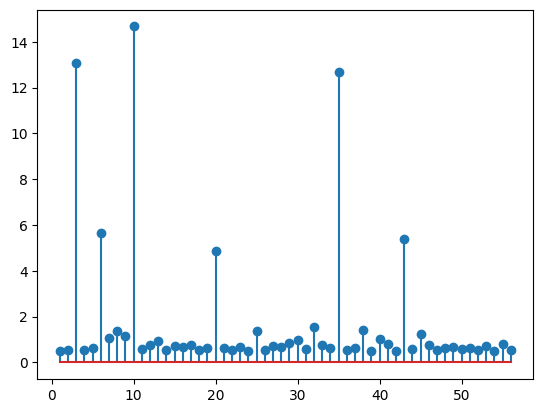

In [298]:
X = np.fft.rfft(W_E, axis=1)             # shape (d_model, p//2 + 1)
k = np.arange(X.real.shape[1])                # 0..56 for p=113
norms = np.linalg.norm(X.real, axis=0, ord=2)        # length p//2 + 1
plt.stem(k[1:], norms[1:])

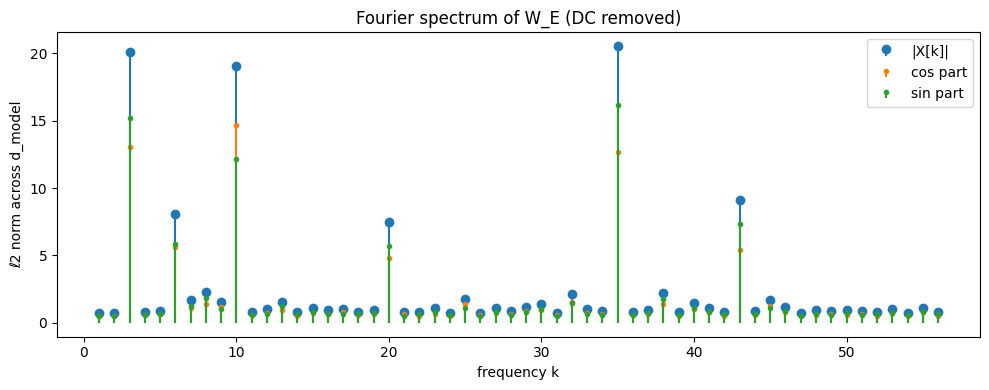

Top 5 frequencies: [35, 3, 10, 43, 6]
Magnitudes:         [20.520000457763672, 20.059999465942383, 19.040000915527344, 9.09000015258789, 8.100000381469727]


In [299]:
import numpy as np
import matplotlib.pyplot as plt

X = np.fft.rfft(W_E, axis=1)                  # (d_model, p//2 + 1)
k = np.arange(X.shape[1])

norm_total = np.linalg.norm(X,      axis=0)   # |X[:,k]|, the natural quantity
norm_cos   = np.linalg.norm(X.real, axis=0)
norm_sin   = np.linalg.norm(X.imag, axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(k[1:], norm_total[1:], linefmt="C0-", markerfmt="C0o", basefmt=" ",
        label="|X[k]|")
ax.stem(k[1:], norm_cos[1:],   linefmt="C1-", markerfmt="C1.", basefmt=" ",
        label="cos part")
ax.stem(k[1:], norm_sin[1:],   linefmt="C2-", markerfmt="C2.", basefmt=" ",
        label="sin part")
ax.set_xlabel("frequency k")
ax.set_ylabel("ℓ2 norm across d_model")
ax.set_title("Fourier spectrum of W_E (DC removed)")
ax.legend()
plt.tight_layout()
plt.show()

# Identify top key frequencies
top_k = np.argsort(norm_total[1:])[-5:][::-1] + 1
print("Top 5 frequencies:", top_k.tolist())
print("Magnitudes:        ", norm_total[top_k].round(2).tolist())

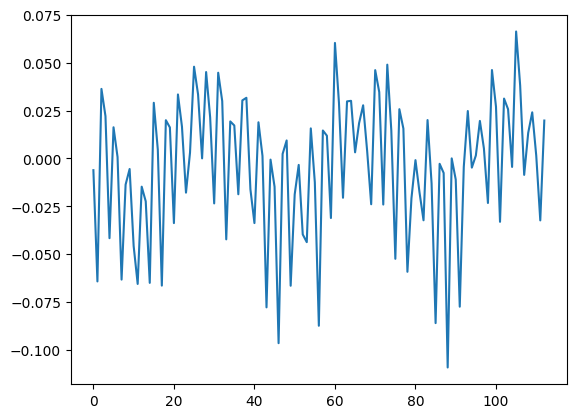

In [300]:
plt.plot(np.arange(0, 113), W_E[32, :])

In [301]:
X = np.fft.fft(W_E, axis=1)
cos_part = X.real    # cosine coefficients
sin_part = X.imag    # sine coefficients

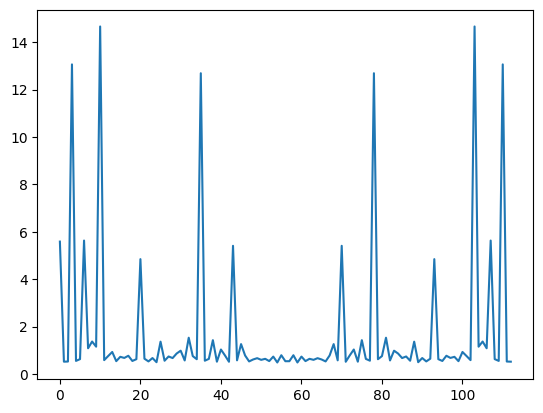

In [302]:
plt.plot(np.arange(0, cos_part.shape[1]), np.linalg.norm(cos_part, axis=0))

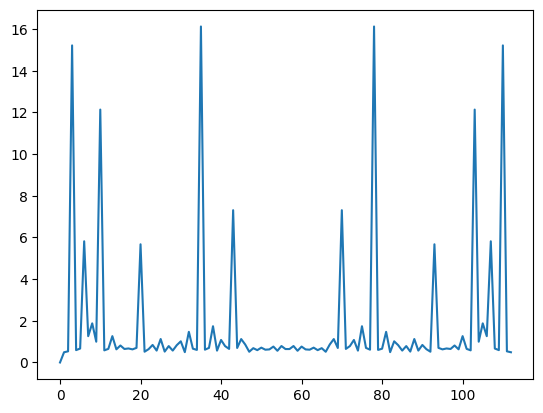

In [303]:
plt.plot(np.arange(0, sin_part.shape[1]), np.linalg.norm(sin_part, axis=0))

In [305]:
import torch, numpy as np

p = 113
device = next(model.parameters()).device

# All p^2 input triples [a, b, p]
A, B = np.meshgrid(np.arange(p), np.arange(p), indexing="ij")
x = torch.tensor(np.stack([A.ravel(), B.ravel(), np.full(p*p, p)], 1),
                 dtype=torch.long, device=device)
y = torch.tensor(((A + B) % p).ravel(), dtype=torch.long, device=device)

def eval_acc(tag):
    model.eval()
    with torch.no_grad():
        out = model(x)
        preds = (out[:, 2, :] if out.ndim == 3 else out).argmax(-1)
    acc = (preds == y).float().mean().item()
    print(f"{tag}: {100*acc:.2f}%  ({(preds == y).sum().item()}/{p*p})")
    return acc

# Quick sanity: confirm output shape before the real eval
print("Output shape:", model(x[:1]).shape)
print("Embedding shape:", model.embedding.weight.shape)

# 1. Baseline
eval_acc("Original model      ")

# 2. Fourier filter on W_E
W_E = extract_W_E(model, p=p)                       # (d_model, p)
X = np.fft.rfft(W_E, axis=1)
mags = np.linalg.norm(X, axis=0); mags[0] = 0
keep = np.argsort(mags)[-5:]
print("Keeping frequencies:", [0, *sorted(keep.tolist())])

mask = np.zeros_like(X)
mask[:, [0, *keep]] = 1
W_E_filt = np.fft.irfft(X * mask, n=p, axis=1)

# 3. Splice in, with backup
w = model.embedding.weight
W_E_backup = w.data.clone()
with torch.no_grad():
    new_rows = torch.from_numpy(W_E_filt.T).to(w.dtype).to(w.device)   # (p, d)
    if w.shape[0] in (p, p + 1):
        w.data[:p] = new_rows
    else:
        w.data[:, :p] = new_rows.T

# 4. Evaluate filtered
eval_acc("Top-5 Fourier filter")

# 5. Restore
w.data.copy_(W_E_backup)
eval_acc("Restored (sanity)   ")

Output shape: torch.Size([1, 3, 113])
Embedding shape: torch.Size([114, 128])
Original model      : 7.32%  (935/12769)
Using model.embedding.weight, shape after slicing: (128, 113)
Keeping frequencies: [0, 3, 6, 10, 35, 43]
Top-5 Fourier filter: 6.23%  (795/12769)
Restored (sanity)   : 7.32%  (935/12769)


0.07322421669960022